# Pakistani Diabetes Dataset Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.makedirs('plots', exist_ok=True) 

### Load the Dataset

In [3]:
df = pd.read_csv("../Datasetss/Pakistani_Diabetes_Dataset.csv")
df.sample(5)

,Age,Gender,Rgn,wt,BMI,wst,sys,dia,his,A1c,B.S.R,vision,Exr,dipsia,uria,Dur,neph,HDL,Outcome
126,34.0,1,1,71.0,27.40,36.0,132,86,0,10.5,234,0,0,1,0,2.5,1,53,1
722,56.0,1,1,60.0,23.70,36.6,156,90,1,8.3,185,0,0,0,0,3.0,0,37,1
911,23.0,1,1,60.0,20.56,31.0,124,73,0,4.0,87,0,0,0,0,0.0,0,44,0
861,21.0,0,1,58.0,20.63,39.0,142,70,1,5.4,90,1,15,0,0,0.0,0,45,0
435,57.0,0,0,95.0,28.40,41.0,130,90,0,5.3,120,1,30,0,0,0.0,0,43,0


### Basic Inspection

In [4]:
df.shape

(912, 19)

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df['Rgn'].unique()

array([0, 1])

In [7]:
df = df.drop(columns = ['Rgn'])
df.sample(5)

,Age,Gender,wt,BMI,wst,sys,dia,his,A1c,B.S.R,vision,Exr,dipsia,uria,Dur,neph,HDL,Outcome
569,20.0,0,70.0,27.51,32.0,130,70,0,4.80,98,0,30,0,0,0.0,0,51,0
496,35.0,0,72.0,24.86,40.0,120,80,0,5.00,95,1,20,0,0,0.0,0,56,0
118,61.0,1,58.0,24.16,34.2,143,93,0,9.50,173,1,0,1,1,6.0,0,39,1
92,46.0,0,85.0,27.67,39.4,141,80,1,7.79,230,1,0,0,1,1.0,0,35,1
26,45.0,1,70.0,28.90,39.0,127,80,0,10.00,220,0,30,0,1,3.0,1,39,1


In [8]:
df.shape

(912, 18)

In [9]:
df.isnull().sum()

Age        0
Gender     0
wt         0
BMI        0
wst        0
sys        0
dia        0
his        0
A1c        0
B.S.R      0
vision     0
Exr        0
dipsia     0
uria       0
Dur        0
neph       0
HDL        0
Outcome    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(2)

#### Check duplicates with original rows

In [11]:
df[df.duplicated(keep=False)]

,Age,Gender,wt,BMI,wst,sys,dia,his,A1c,B.S.R,vision,Exr,dipsia,uria,Dur,neph,HDL,Outcome
2,58.0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0
3,27.0,0,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0
377,58.0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0
492,27.0,0,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0


#### Remove Duplicates to prevent redundancy

In [12]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Basic EDA

#### *Update Column Names for better understanding*

In [13]:
# Update Column names
rename_dict = {
    'wt': 'Weight_kg',
    'wst': 'Waist_inches',
    'sys': 'Systolic_BP',
    'dia': 'Diastolic_BP',
    'his': 'Family_History',
    'A1c': 'HbA1c_Level',
    'B.S.R': 'Blood_Sugar_Random',
    'vision': 'Vision_Impact',
    'Exr': 'Exercise_Duration',
    'dipsia': 'Polydipsia_Excessive_Thirst',
    'uria': 'Polyuria_Frequent_Urination',
    'Dur': 'Diabetes_Duration_Years',
    'neph': 'Nephropathy_Kidney_Impact',
    'HDL': 'HDL_Good_Cholesterol'
}

# Rename Column
df.rename(columns=rename_dict, inplace=True)

# check new Column names
print(df.columns)

Index(['Age', 'Gender', 'Weight_kg', 'BMI', 'Waist_inches', 'Systolic_BP',
       'Diastolic_BP', 'Family_History', 'HbA1c_Level', 'Blood_Sugar_Random',
       'Vision_Impact', 'Exercise_Duration', 'Polydipsia_Excessive_Thirst',
       'Polyuria_Frequent_Urination', 'Diabetes_Duration_Years',
       'Nephropathy_Kidney_Impact', 'HDL_Good_Cholesterol', 'Outcome'],
      dtype='str')


#### Diabetic vs Non-diabetic

In [14]:
df['Outcome'].value_counts(normalize=True).round(2)*100

Outcome
1    53.0
0    47.0
Name: proportion, dtype: float64

* **53% Diabatic**
* **47% Non Diabetic**

### Data Summery

In [15]:
df.describe()

,Age,Gender,Weight_kg,BMI,Waist_inches,Systolic_BP,Diastolic_BP,Family_History,HbA1c_Level,Blood_Sugar_Random,Vision_Impact,Exercise_Duration,Polydipsia_Excessive_Thirst,Polyuria_Frequent_Urination,Diabetes_Duration_Years,Nephropathy_Kidney_Impact,HDL_Good_Cholesterol,Outcome
count,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000
mean,36.304945,0.552747,69.369451,25.632611,35.470879,129.652747,82.352747,0.586813,6.863297,165.587912,0.489011,14.423077,0.380220,0.328571,2.117582,0.171429,45.939560,0.534066
std,13.513210,0.497483,12.179145,8.255834,3.893985,19.768803,11.834380,0.492677,2.197677,84.779793,0.500154,15.617897,0.485708,0.469952,2.966497,0.377090,6.799799,0.499112
min,12.000000,0.000000,30.000000,2.840000,24.000000,90.000000,20.000000,0.000000,0.100000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000
25%,22.250000,0.000000,60.000000,22.512500,32.500000,120.000000,73.250000,0.000000,5.000000,96.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,41.000000,0.000000
50%,36.000000,1.000000,69.000000,25.260000,35.000000,126.000000,80.000000,1.000000,6.100000,131.000000,0.000000,15.000000,0.000000,0.000000,1.000000,0.000000,46.000000,1.000000
75%,48.000000,1.000000,77.000000,28.300000,38.000000,138.000000,90.000000,1.000000,8.500000,217.750000,1.000000,25.000000,1.000000,1.000000,3.500000,0.000000,51.000000,1.000000
max,70.000000,1.000000,110.000000,233.790000,67.000000,245.000000,115.000000,1.000000,14.000000,464.000000,1.000000,120.000000,1.000000,1.000000,25.000000,1.000000,62.000000,1.000000



* Age ranges 12–70 , average 36 , mixed young and adult diabetics. 
* Gender is binary (0/1), slightly more males (mean 0.55). 
* BMI max of 233 is a clear outlier , needs investigation. 
* A1c (HbA1c_Level) mean is 6.86, which is in the pre-diabetic/diabetic range. 
* B.S.R (Blood Sugar) has a wide spread (70–464), showing high variability. 
* Several columns like his, vision, dipsia, uria, neph are binary (0/1 flags). 
* Outcome mean is 0.53 , nearly balanced classes, which is good for ML.

In [16]:
print(df['BMI'].sort_values(ascending=False).head(10))

472    233.79
67      49.61
119     40.90
58      38.20
700     38.20
738     37.45
109     37.45
60      37.21
702     37.21
74      37.07
Name: BMI, dtype: float64


In [17]:
# remove the outlier
df = df[df['BMI']<60]
print(f"Rows removed: {912 - len(df)}")


Rows removed: 3


#### BMI Distribution without Outlier

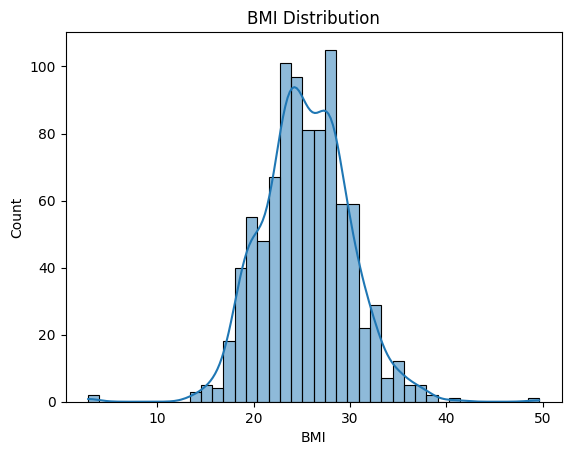

In [18]:
# histplot after removing outlier
sns.histplot(df['BMI'], kde=True)
plt.title('BMI Distribution')
plt.show()

### Family History vs Diabetes

In [19]:
pd.crosstab(df['Family_History'] , df['Outcome'])

Outcome,0,1
Family_History,,
0,204,171
1,219,315


### Insight: Family History vs Diabetes Outcome

| Group               | Non-Diabetic | Diabetic | Diabetes Rate |
|---------------------|-------------|----------|---------------|
| No family history   | 206         | 171      | 45%           |
| Has family history  | 219         | 315      | 59%           |

- Those with family history have a **59% diabetes rate** vs **45%** without — 
  a 14 percentage point difference.
- Family history is a risk factor in this data, but not deterministic — 
  41% with family history are still non-diabetic.
- This column is worth including as a feature in the ML model.

### Diabetes Impact on Vision

In [20]:
ct = pd.crosstab(df['Vision_Impact'], df['Outcome'], normalize='index').round(2)
print(ct)

Outcome           0     1
Vision_Impact            
0              0.53  0.47
1              0.40  0.60


### Insight: Vision Impact vs Diabetes

| Vision Impact | Non-Diabetic | Diabetic |
|---|---|---|
| No (0) | 53% | 47% |
| Yes (1) | 40% | 60% |

- Patients with vision impact have a 60% diabetes rate vs 47% without ,
  a 13 percentage point difference.

#### Check Diabetes Agewise

In [21]:
bins = [10,20,30,40,50,60,80]
df.groupby(pd.cut(df['Age'], bins=bins))['Outcome'].agg(['mean', 'count'])

,mean,count
Age,,
"(10, 20]",0.037736,53
"(20, 30]",0.055901,322
"(30, 40]",0.740741,162
"(40, 50]",0.943396,212
"(50, 60]",0.896296,135
"(60, 80]",1.000000,25


### Insight: Diabetes Rate by Age Group

- Age 10–30: Very low prevalence (4%–6%). Low-risk group in this dataset.
- Age 30–40: Sharp jump to 74% , the critical turning point. Warrants deeper
  investigation with BMI, exercise (Exr), and duration (Dur) columns.
- Age 40–60: High-risk zone (88%–94%). Consistent with clinical expectations.
- Age 60–80: 100% rate , **interpret with caution**.

**Note:** Causation cannot be inferred from this plot alone.

In [22]:
# Feature vs target relation
corr_with_outcome = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
corr_with_outcome.round(2)


HbA1c_Level                    0.81
Age                            0.77
Blood_Sugar_Random             0.74
Diabetes_Duration_Years        0.67
Polydipsia_Excessive_Thirst    0.61
Waist_inches                   0.55
Polyuria_Frequent_Urination    0.54
BMI                            0.43
Nephropathy_Kidney_Impact      0.41
Systolic_BP                    0.37
Gender                         0.32
Diastolic_BP                   0.28
Weight_kg                      0.17
Vision_Impact                  0.14
Family_History                 0.13
Exercise_Duration             -0.07
HDL_Good_Cholesterol          -0.44
Name: Outcome, dtype: float64

In [23]:
# Feature vs feature relation

# Multicollinearity check — pairs above 0.7
corr_matrix = df.corr().abs()
high_corr = (corr_matrix
             .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
             .stack()
             .sort_values(ascending=False))
print("\nHighly correlated pairs (>0.7):")
print(high_corr[high_corr > 0.7])


Highly correlated pairs (>0.7):
HbA1c_Level         Outcome               0.811223
                    Blood_Sugar_Random    0.792502
Age                 Outcome               0.767319
Blood_Sugar_Random  Outcome               0.743264
dtype: float64


### Correlation with Outcome

- HbA1c (0.81) and Blood_Sugar_Random (0.74) are the strongest predictors.
- These two features also correlate with each other at 0.79 , multicollinearity risk.
  Will monitor this during model selection.
- HDL is the only negative predictor (-0.44): higher good cholesterol = lower diabetes risk.
- Exercise_Duration shows near-zero correlation (-0.07) , may be dropped after feature selection.
- Family_History shows weaker correlation (0.14) than expected clinically.

### High Exercise Time

In [24]:
df[df['Exercise_Duration']==120]

,Age,Gender,Weight_kg,BMI,Waist_inches,Systolic_BP,Diastolic_BP,Family_History,HbA1c_Level,Blood_Sugar_Random,Vision_Impact,Exercise_Duration,Polydipsia_Excessive_Thirst,Polyuria_Frequent_Urination,Diabetes_Duration_Years,Nephropathy_Kidney_Impact,HDL_Good_Cholesterol,Outcome
236,43.0,1,68.0,28.30,38.0,204,99,0,7.6,188,1,120,1,1,4.0,1,45,1
531,23.0,0,67.0,18.68,32.0,120,80,1,4.2,88,1,120,0,0,0.0,0,41,0


### Insight:
* Unusual observation with **120 minutes of excercise** but still **High B.P and High B.S.R**

### Exercise & Diabetes

In [25]:
no_ex_diabetic = len(df[(df['Exercise_Duration'] == 0) & (df['Outcome'] == 1)])
total_diabetic = len(df[df['Outcome'] == 1])
no_ex_total = len(df[df['Exercise_Duration'] == 0])

print(f"Non-exercisers who are diabetic: {no_ex_diabetic/no_ex_total:.0%}")
print(f"Diabetics who don't exercise: {no_ex_diabetic/total_diabetic:.0%}")

Non-exercisers who are diabetic: 61%
Diabetics who don't exercise: 52%


### Distribution Plots for all Numeric Columns

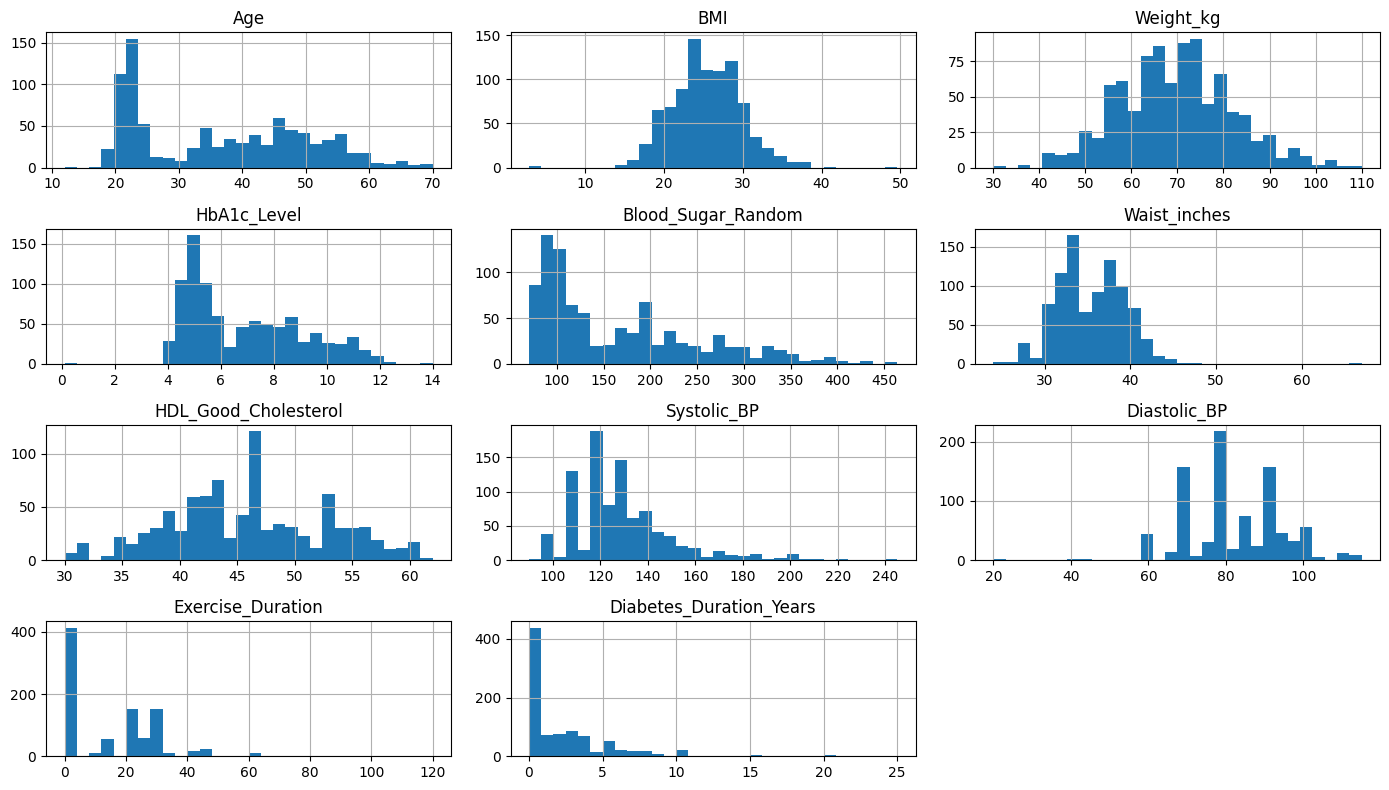

In [26]:
num_cols = ['Age', 'BMI','Weight_kg' , 'HbA1c_Level', 'Blood_Sugar_Random', 
            'Waist_inches', 'HDL_Good_Cholesterol' , 'Systolic_BP' , 'Diastolic_BP' ,
            'Exercise_Duration' , 'Diabetes_Duration_Years']

df[num_cols].hist(bins=30, figsize=(14, 8))
plt.tight_layout()

# save the chart
plt.savefig('plots/distribution.png', bbox_inches='tight')

plt.show()

### General Health & Physical Metrics
* **BMI & Weight:** Both BMI and Weig follow a near-perfect Normal Distribution.Most patients have a BMI between 20 and 30, and their weight mostly clusters around 60–80 kg.
  
* **Waist Inches:** This graph shows a bimodal tendency  This likely splits the dataset into two distinct physical groups (e.g., males vs. females, or healthy weight vs. overweight individuals).

* **HbA1c & Random Sugar:** Heavily Right-Skewed with long tails. A large group is healthy (HbA1c around 5%), but a continuous stretch of patients has dangerously high, uncontrolled sugar levels.

* **Blood Pressure (Systolic & Diastolic):** The choppy bars with empty gaps reveal data rounding bias, meaning doctors recorded exact numbers like 70, 80, 120, or 130 instead of precise individual readings.

* **Exercise Duration:** Dominated by a massive spike at 0 minutes, showing that a vast majority of the individuals in this dataset live a completely sedentary lifestyle.

* **Diabetes Duration:** Mostly clustered at 0 years, proving that most diabetic patients in this records are newly diagnosed cases.

### Boxplot 1 — Overall Distribution (all columns together)
*Purpose: spot outliers and spread across all numeric features at once*

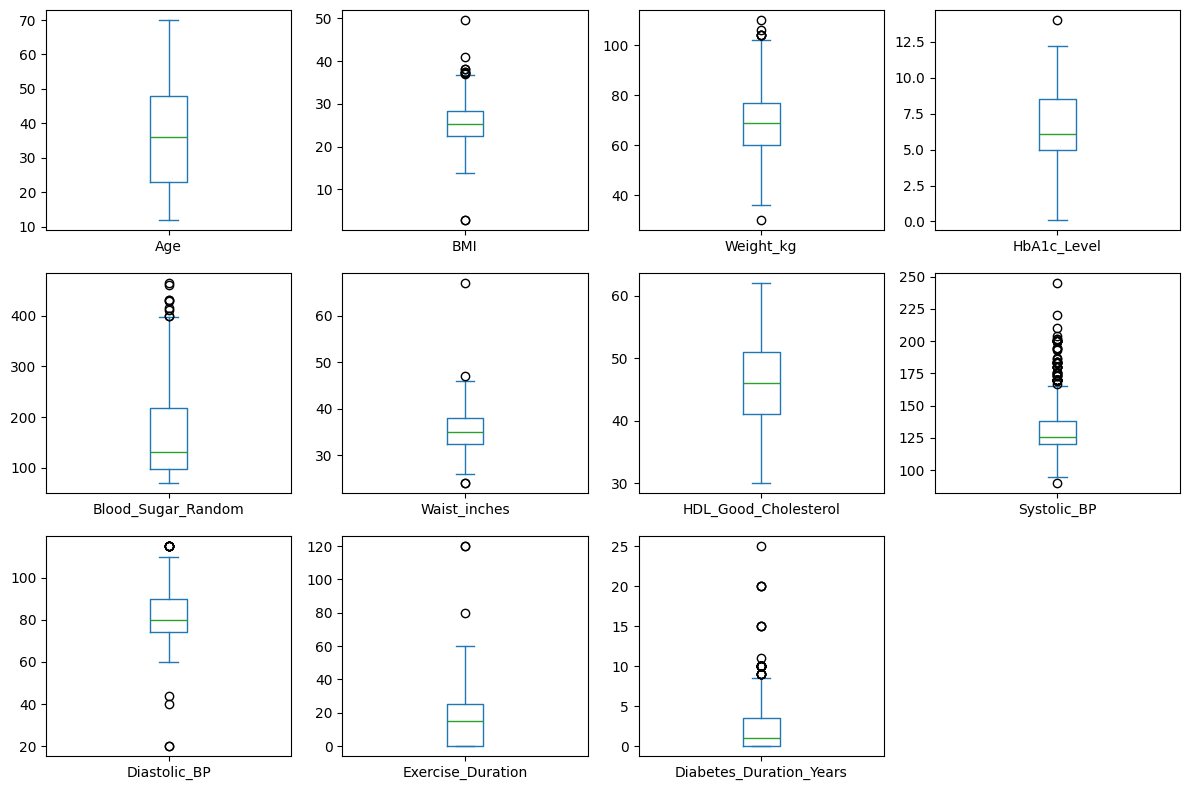

In [27]:

df[num_cols].plot(
    kind = 'box' ,
    subplots= True ,
    layout= (3,4) ,
    figsize= (12,8)
    )
plt.tight_layout()
plt.savefig('plots/combined_boxplots.png' , bbox_inches= 'tight')
plt.show()


### Boxplot 2 — Each Feature vs Outcome (diabetic vs non-diabetic)
*Purpose: see which features separate diabetic from non-diabetic patients*

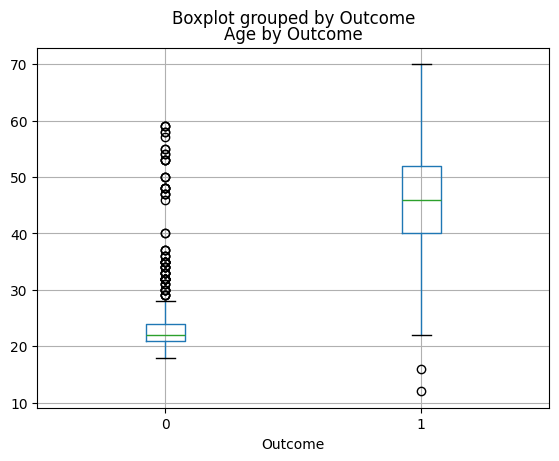

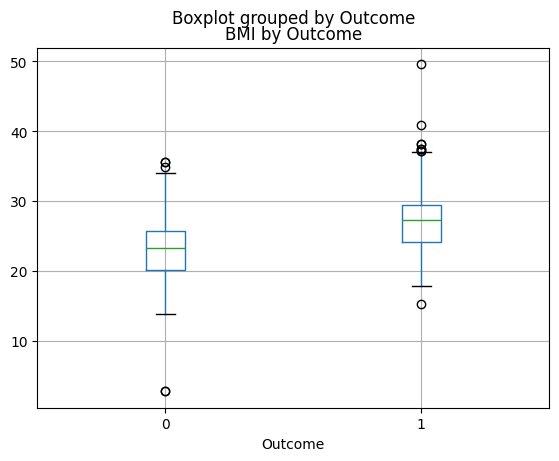

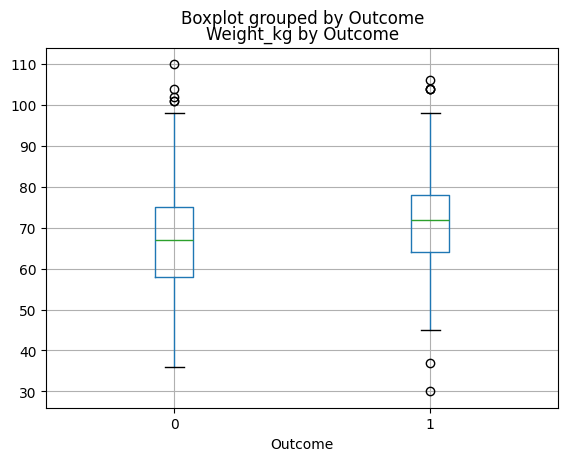

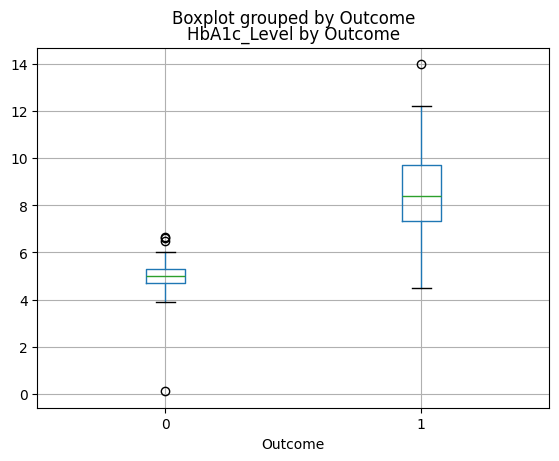

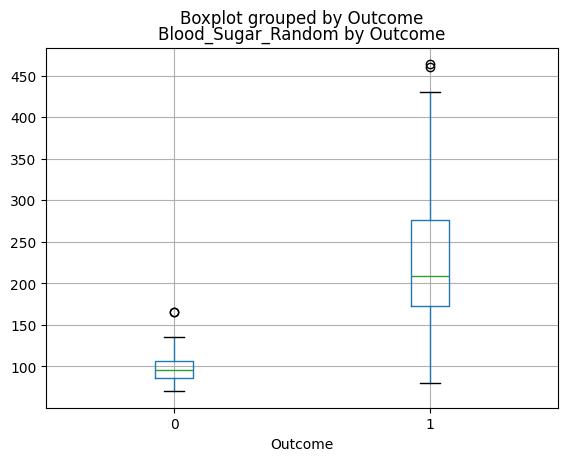

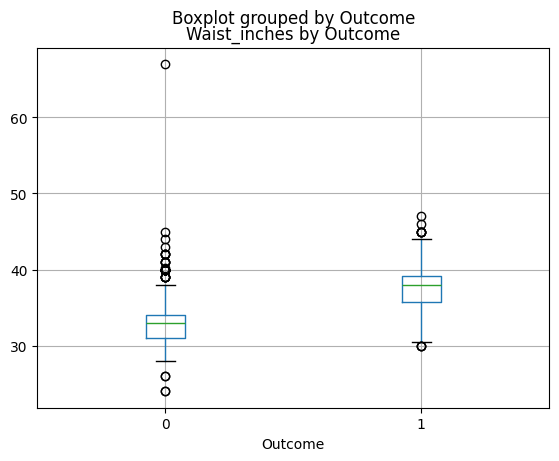

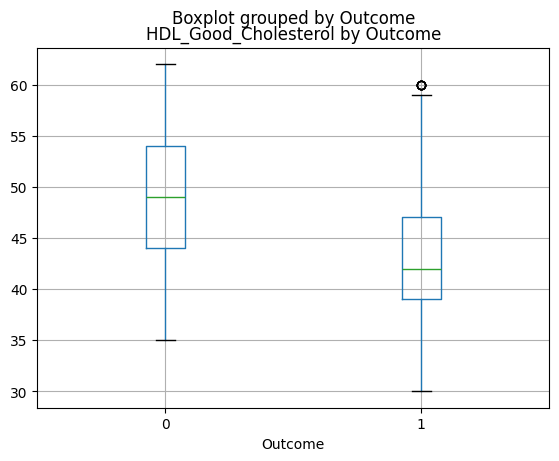

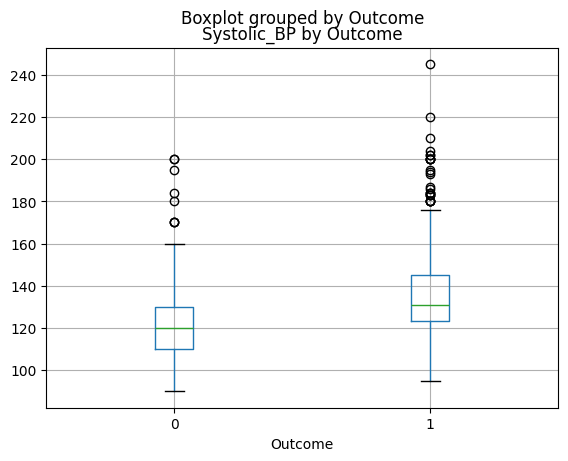

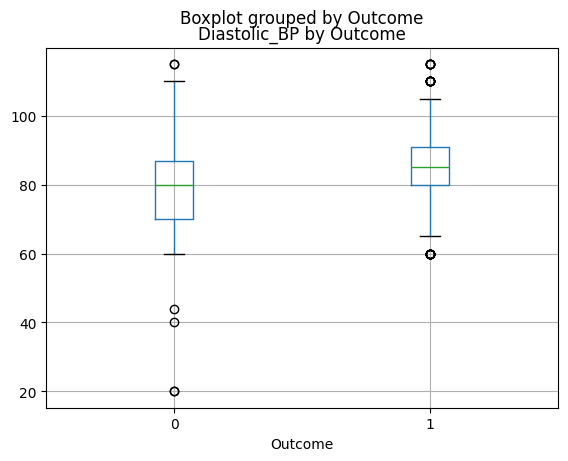

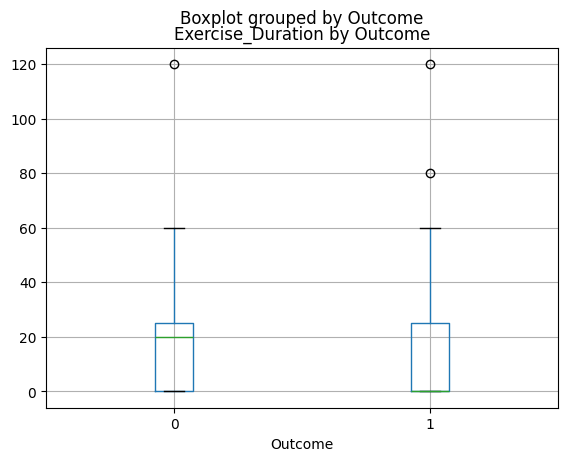

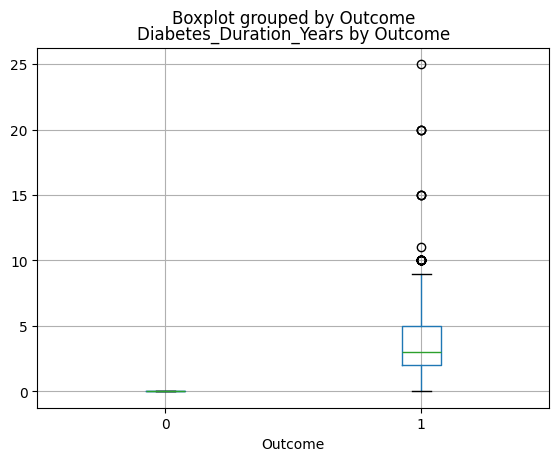

In [28]:
for col in num_cols:
    df.boxplot(column=col, by='Outcome')
    plt.title(f'{col} by Outcome')
    plt.show()

### Boxplot Insights

- HbA1c and Blood_Sugar_Random show clear separation between Outcome 0 and 1 ,
  confirms their predictive strength.
- Age median is visibly higher in diabetic group.
- HDL median is lower in diabetic group , consistent with negative correlation (-0.44).
- Exercise_Duration shows minimal separation , weak predictor visually confirmed.

### Young Diabetic

In [29]:
# young diabetic
df[(df['Age']<= 20) & (df['Outcome']==1)]

,Age,Gender,Weight_kg,BMI,Waist_inches,Systolic_BP,Diastolic_BP,Family_History,HbA1c_Level,Blood_Sugar_Random,Vision_Impact,Exercise_Duration,Polydipsia_Excessive_Thirst,Polyuria_Frequent_Urination,Diabetes_Duration_Years,Nephropathy_Kidney_Impact,HDL_Good_Cholesterol,Outcome
28,16.0,1,50.0,20.16,36.0,160,85,0,7.5,192,0,0,1,0,1.0,0,42,1
44,12.0,1,30.0,15.37,30.0,145,95,1,7.3,115,1,0,1,1,2.5,0,47,1


In [30]:
# young diabetic
young_diabetic = df[(df['Age'] <= 20) & (df['Outcome'] == 1)]

print("Count:", len(young_diabetic))
print("Total under 20:", len(df[df['Age'] <= 20]))
print("Diabetes rate under 20:", len(young_diabetic) / len(df[df['Age'] <= 20]))

Count: 2
Total under 20: 53
Diabetes rate under 20: 0.03773584905660377


### Young Diabetics (Age ≤ 20)
* Only 2 out of 53 young patients (under 20) are diabetic — 3.8% rate.
 * Clinical note: low BMI in one patient (15.37, age 12) suggests possible
  Type 1 diabetes — a genetic condition unrelated to lifestyle factors.
  This dataset does not distinguish between Type 1 and Type 2.


In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 909 entries, 0 to 911
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          909 non-null    float64
 1   Gender                       909 non-null    int64  
 2   Weight_kg                    909 non-null    float64
 3   BMI                          909 non-null    float64
 4   Waist_inches                 909 non-null    float64
 5   Systolic_BP                  909 non-null    int64  
 6   Diastolic_BP                 909 non-null    int64  
 7   Family_History               909 non-null    int64  
 8   HbA1c_Level                  909 non-null    float64
 9   Blood_Sugar_Random           909 non-null    int64  
 10  Vision_Impact                909 non-null    int64  
 11  Exercise_Duration            909 non-null    int64  
 12  Polydipsia_Excessive_Thirst  909 non-null    int64  
 13  Polyuria_Frequent_Urination  909 non

## EDA Summary

| Feature | Key Finding | ML Action |
|---|---|---|
| HbA1c_Level | Strongest predictor (0.81) | Keep |
| Age | Strong predictor (0.76) | Keep |
| Blood_Sugar_Random | High corr (0.74), multicollinear with HbA1c | Monitor |
| HDL_Good_Cholesterol | Negative predictor (-0.44) | Keep |
| BMI | Outlier removed (>60) | Keep |
| Exercise_Duration | Weak corr (-0.07), 45% zeros | Keep, review in feature selection |
| Family_History | Weaker than expected (0.14) | Keep |

**Data shape after cleaning:** 909 rows × 18 columns  
**Next step:** Preprocessing → Model Training